<center> Assessment 01 </center>

In [157]:
Assignment_number: "01"
Name: "Saloni Borwankar"
Student_ID: "48120901"

<center> Acknowledgement Statement by Student: </center>

<center>I acknowledge that I have only used GAITs (e.g., ChatGPT) in drafting and proofreading this assignment, which is permitted in the assignment instructions. </center>

### 1. Data Cleansing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

**1.1 Loading the Data**

In [4]:
# firstly, we'll load the data
customer = pd.read_csv(r"Assignment_\customer_shopping_data.csv")
customer.head(2)# displaying the first 2 rows of data set

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,8/05/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul


In [5]:
customer.shape # total number of rows and colomns

(99461, 10)

**1.2 Handling missing values**

In [7]:
customer.info() #finding out missing value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99461 entries, 0 to 99460
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99461 non-null  object 
 1   customer_id     99461 non-null  object 
 2   gender          99461 non-null  object 
 3   age             99461 non-null  int64  
 4   category        99461 non-null  object 
 5   quantity        99461 non-null  int64  
 6   price           99459 non-null  float64
 7   payment_method  99460 non-null  object 
 8   invoice_date    99461 non-null  object 
 9   shopping_mall   99461 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


In [8]:
# checking missing values
missing_values = customer.isnull().sum()
missing_values[missing_values > 0]

price             2
payment_method    1
dtype: int64

In [9]:
# Filling missing_values with cloumn's median.

customer['price'] = customer['price'].fillna(customer['price'].median()) # using median since mean has outliers

# Considering that cash should be the missing value in the payment method since it is not recorded.
customer['payment_method'] = customer['payment_method'].fillna('Cash')

In [10]:
print(f"Number of missing values in 'price': {customer['price'].isnull().sum()}") # number of missing values in price 
print(f"Number of missing values in 'payment_method'{customer['payment_method'].isnull().sum()}") #  missing values in payment_method

Number of missing values in 'price': 0
Number of missing values in 'payment_method'0


In [11]:
customer.nunique() # finding unique values in the CS data

invoice_no        99458
customer_id       99457
gender                3
age                  53
category             15
quantity              5
price                41
payment_method        6
invoice_date        812
shopping_mall        11
dtype: int64

In [12]:
# This is being done to check invalid customer ID
pattern = r'C\d{6}$'

customer['customer_id_valid'] = customer['customer_id'].astype(str).str.match(pattern).fillna(False).astype(bool)
print (customer[~customer['customer_id_valid']])

      invoice_no customer_id  gender  age   category  quantity  price  \
99418    I166977     C2061##  Female   34  Cosmetics         5  203.3   

      payment_method invoice_date shopping_mall  customer_id_valid  
99418    Credit Card        44597        Kanyon              False  


In [13]:
# Removing the invalid customer ID 
# Since the data is large, removing the invalid customer ID won't have any impact on it.
customer = customer[customer['customer_id_valid']]
customer = customer.drop(columns=['customer_id_valid']) 


In [14]:
customer.info() # Removing the invalid customer ID successfully. 

<class 'pandas.core.frame.DataFrame'>
Index: 99460 entries, 0 to 99460
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99460 non-null  object 
 1   customer_id     99460 non-null  object 
 2   gender          99460 non-null  object 
 3   age             99460 non-null  int64  
 4   category        99460 non-null  object 
 5   quantity        99460 non-null  int64  
 6   price           99460 non-null  float64
 7   payment_method  99460 non-null  object 
 8   invoice_date    99460 non-null  object 
 9   shopping_mall   99460 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 8.3+ MB


**1.3 Data Type Conversion**

In [16]:
print(customer.columns) # This is done to check the unique columns 

Index(['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity',
       'price', 'payment_method', 'invoice_date', 'shopping_mall'],
      dtype='object')


In [17]:
# Converting 'age' and 'price' columns to numeric types 
customer['age'] = pd.to_numeric(customer['age'], errors='coerce')
customer['price'] = pd.to_numeric(customer['price'], errors='coerce')

In [18]:
# Converting 'gender' to a categorical data type
customer['gender'] = customer['gender'].astype('category')

In [19]:
# Replacement of 'invoice_date' with the actual name of the date column
# Replacing invalid dates_data to NaT(Null)
customer['invoice_date'] = pd.to_datetime(customer['invoice_date'], format='%m/%d/%Y', errors='coerce')

# display conversion 
customer['invoice_date'].head()

0   2022-08-05
1   2021-12-12
2   2021-11-09
3   2021-05-16
4   2021-10-24
Name: invoice_date, dtype: datetime64[ns]

In [20]:
# Finding out the number of invalid dates
invalid_dates = customer['invoice_date'].isnull().sum()
print(f"invalid dates after conversion: {invalid_dates}")

invalid dates after conversion: 15


**1.4 Duplicate Records**

*Duplicate entires can lead to incorrect business decisions. Identifying and removing duplicates is a fundamental step in data cleaning, ensuring that the dataset is as accurate and reliable as possible.* 

In [23]:
# Checking duplicates on the basis of invoice_no and customer_id
duplicates = customer[customer.duplicated(subset = ['invoice_no','customer_id'], keep = False)]
duplicates.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
236,I218385,C290280,Female,51,Toys,1,35.84,Cash,NaT,Metrocity
237,I218385,C290280,Female,51,Toys,1,35.84,Cash,2022-07-19,Metrocity
249,I120948,C340089,Female,54,Shoe,4,2400.68,Debit Card,NaT,Mall of Istanbul
250,I120948,C340089,Female,54,Shoes,4,2400.68,Debit Card,2021-08-08,Mall of Istanbul
99389,I170876,C320288,Male,40,Food,3,15.69,Cash,NaT,Metrocity


**1.4 Handling Duplicates & Null Values**

In [25]:
# Droping duplicates
customer = customer.drop_duplicates(subset = ['invoice_no','customer_id'])
customer.head(2)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul


In [26]:
# droping Null values
customer = customer.dropna()
customer.shape

(99442, 10)

**1.5  Similar Records**

In [166]:
# Replacing similar names into common names
# correcting inconsistent or incorrect entries in the columns payment_method, gender, and shopping_mall
customer['payment_method'] = customer['payment_method'].replace('Cash Cash', 'Cash') 
customer['payment_method'] = customer['payment_method'].replace('CreditCard', 'Credit Card')
customer['gender'] = customer['gender'].replace('Mal', 'Male')
customer['shopping_mall'] = customer['shopping_mall'].replace('Mall Istanbul', 'Mall of Istanbul')

In [168]:
# used to map incorrect or abbreviated category names to their correct full names.
replacements = {'Toy': 'Toys','Clothi': 'Clothing','Boks': 'Books','Cosmetic': 'Cosmetics','Food': 'Food & Beverage','Shoe': 'Shoes','Tech': 'Technology'}
# Replacement of values in the 'categories' column
customer['category'] = customer['category'].replace(replacements)
# updated DataFrame
customer.head(2)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,log_price,age_group,month_year
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon,7.314153,26-35,2022-08
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,7.496380,18-25,2021-12


In [30]:
customer['category'].unique() #finding out the number of unique categories

array(['Clothing', 'Shoes', 'Books', 'Cosmetics', 'Food & Beverage',
       'Toys', 'Technology', 'Souvenir'], dtype=object)

**1.6 Data Distribution**

**Histograms** will help in identifying outliers or unusual data points that may need further investigation. The shape of the histogram can indicate whether the data is skewed to the left or right, which has implications for statistical analysis and modeling

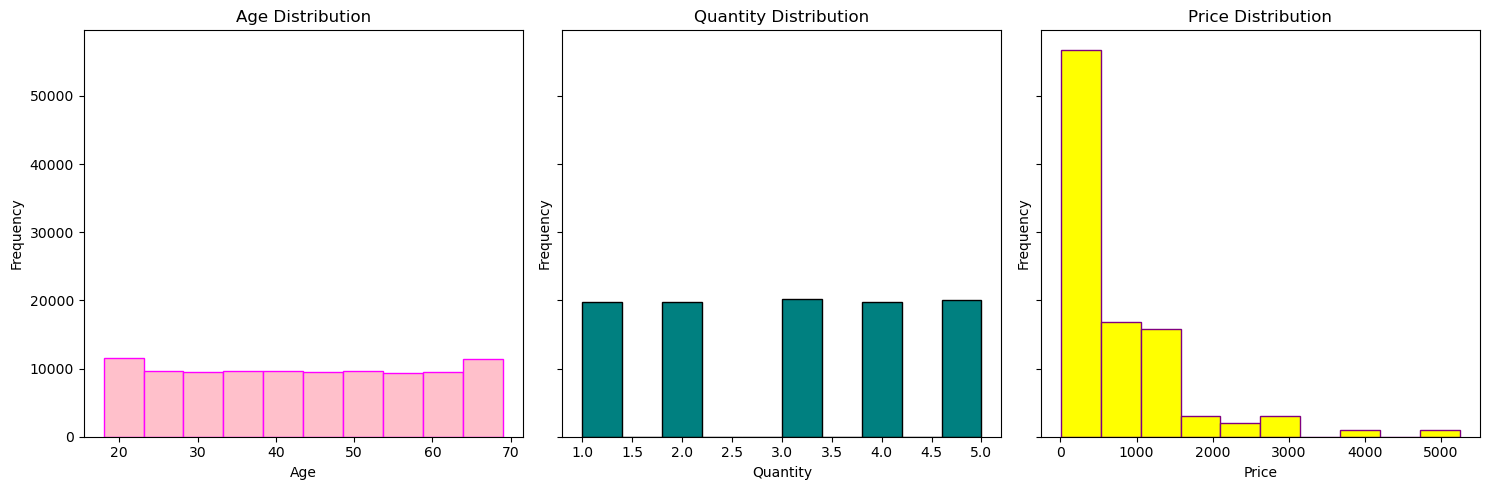

In [33]:
import matplotlib.pyplot as plt

# figure and set of subplots
fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

# Plot histogram for 'age'
axes[0].hist(customer['age'], edgecolor='magenta', color='pink')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].grid(False)

# Plot histogram for 'quantity'
axes[1].hist(customer['quantity'], edgecolor='black', color='teal')
axes[1].set_title('Quantity Distribution')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Frequency')
axes[1].grid(False)

# Plot histogram for 'price'
axes[2].hist(customer['price'], edgecolor='purple', color='yellow')
axes[2].set_title('Price Distribution')
axes[2].set_xlabel('Price')
axes[2].set_ylabel('Frequency')
axes[2].grid(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

**Observations:** In age distribution, bars of nearly equal height across different ages, suggesting a uniform distribution with no outliers. The quantities are distributed evenly, showing little to no skewness. Price distribution is positively skewed (right-skewed), most of the data points are concentrated on the lower price values, with fewer higher prices.

**1.7 Boxplot for each category**

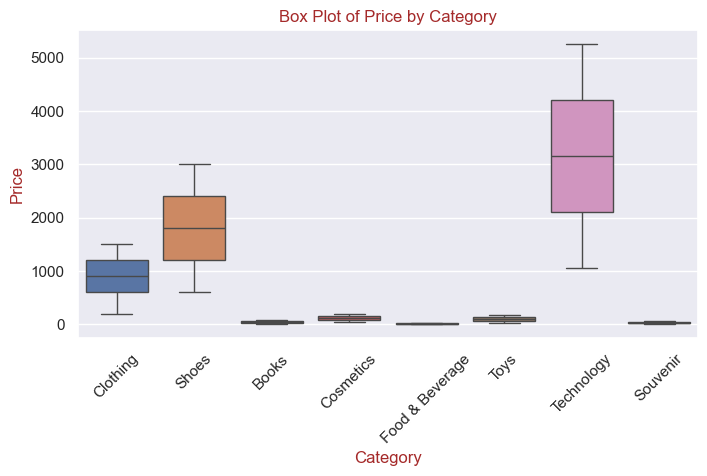

In [36]:
# Plot box plot for each category
import seaborn as sns
plt.figure(figsize=(8, 4))
sns.set(style='darkgrid')
sns.boxplot(x='category', y='price', data=customer, hue = 'category')
plt.title('Box Plot of Price by Category',color='brown')
plt.xlabel('Category', color='brown')
plt.ylabel('Price', color='brown')
plt.xticks(rotation=45)
plt.show()


**Observations:** Based on the plot, Technology is the category where customers might spend the most money on individual items, whereas categories like Books and Cosmetics tend to have much lower prices.

**1.8 Outliers**  

In [39]:
# detecting outliers
# Initializing an empty dictionary to store outliers for each column
def detect_outliers(customer):
    outliers = {}
    for column in customer.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = customer[column].quantile(0.25) # (Q1 - 25th percentile)
        Q3 = customer[column].quantile(0.75) # (Q3 - 75th percentile)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_indices = customer[(customer[column] < lower_bound) | (customer[column] > upper_bound)].index
        outliers[column] = customer.loc[outlier_indices, column]
    return outliers

outliers = detect_outliers(customer)
for column, data in outliers.items():
    print(f"Outliers detected in {column}:")
    print(data)
    print("\n")

Outliers detected in age:
Series([], Name: age, dtype: int64)


Outliers detected in quantity:
Series([], Name: quantity, dtype: int64)


Outliers detected in price:
3        3000.85
15       3000.85
23       5250.00
53       4200.00
69       5250.00
          ...   
99335    3000.85
99377    3150.00
99391    3150.00
99428    3150.00
99459    4200.00
Name: price, Length: 5024, dtype: float64




**Observations:** Only one outlier was detected in the age column, which has a value of 99. This suggests that the typical range of ages in the dataset is much lower than 99, and the individual with an age of 99 is considered an outlier based on the IQR method. The significant number of outliers in the price column indicates that this column may have a wide variability, which could reflect different types of products being priced at vastly different levels.

**Note:** On the basis of category, price may not have any outliers. However, a lot of outliers can be detected in technology price since it's higher than the other categories. 

**1.9 Skewness**

In [42]:
# Calculate skewness

quantity_skewness = customer['quantity'].skew()
price_skewness = customer['price'].skew()
print(f'Quantity Skewness: {quantity_skewness}')
print(f'Price Skewness: {price_skewness}')

Quantity Skewness: -0.001281872870941698
Price Skewness: 2.2474545588583963


**Observations:** Quantity skewness indicates that the distribution of the quantity column is nearly symmetrical. Price has a positive skewness value, and it's quite large (greater than 1), indicating that the distribution of the price column is strongly skewed to the right. This means that most of the price values are concentrated on the lower end, but there are a significant number of high-price values creating a long tail on the right side of the distribution.

Now, to reduce the skewness of the price column using a log transformation, we can apply the logarithm to the price values. Log transformation is particularly useful for handling positive skewness, as it compresses the range of the data and reduces the impact of extreme high values.

In [45]:
# log transformation 

# Adding 1 to the price to handle any zero or negative values
customer['log_price'] = np.log1p(customer['price'])  # log1p(x) = log(1 + x)

# Check the skewness after transformation
log_price_skewness = customer['log_price'].skew()
print(f'Log-Transformed Price Skewness: {log_price_skewness}')

# Display the first few rows of the transformed data
print(customer[['price', 'log_price']].head())

Log-Transformed Price Skewness: -0.23263373520375163
     price  log_price
0  1500.40   7.314153
1  1800.51   7.496380
2   300.08   5.707376
3  3000.85   8.006984
4    60.60   4.120662


This suggests that the distribution of the log-transformed price is now much more symmetric than the original distribution, where the skewness was 2.2475 (strongly positively skewed).

### Overall Summary:
1. Missing values: Addressed all missing values—mean imputation for 2 missing prices, and "cash" for 1 missing payment_method. Removed an invalid customer ID.
2. Data Conversion: Converted invoice_date to datetime64[ns].
3. Duplicates & Nulls: Removed 3 duplicates and 15 null values, which had minimal impact due to the large dataset.
4. Data Distribution: Analyzed with histograms and boxplots.
5. Outliers: No outliers in Age and Quantity; 5,024 in Price but not removed as they were not category-specific.
6. Skewness: Fixed Price skewness with log transformation; Quantity had no skewness.

 ### **2. Descriptive Statistics & Data Exploration** 

**2.1 Spending scores by gender**

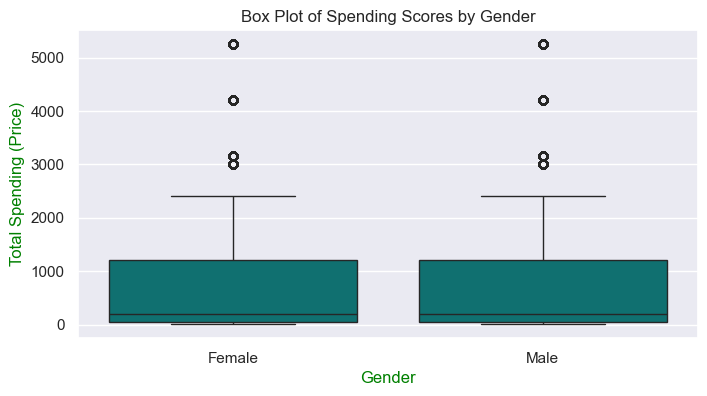

In [51]:
# comparison in distribution of spending between male & female.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))  # figure size for better visualization
sns.boxplot(x='gender', y='price', color= 'teal' , data=customer)  #  box plot with gender on x-axis and spending on y-axis
plt.title('Box Plot of Spending Scores by Gender')  # title of the plot
plt.xlabel('Gender' , color='green')  # Label for the x-axis
plt.ylabel('Total Spending (Price)' , color='green')  # Label for the y-axis
plt.show() # displaying boxplot

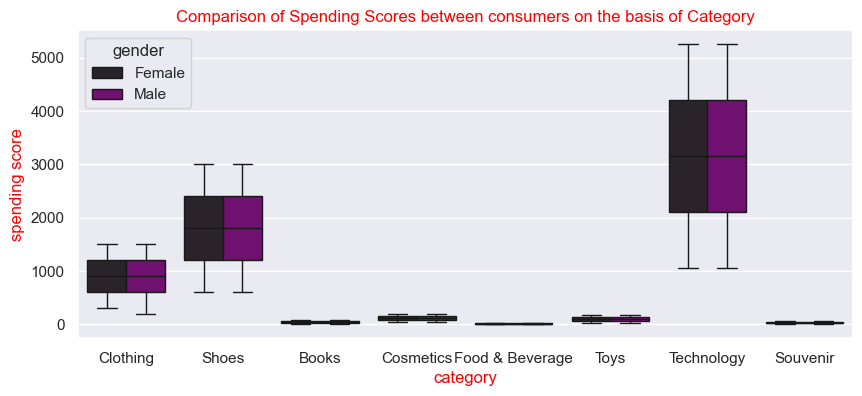

In [202]:
plt.figure(figsize=(10, 4)) 
sns.boxplot(x='category', y='price',  hue='gender' , palette='dark:purple' , data=customer) 
plt.title('Comparison of Spending Scores between consumers on the basis of Category' , color='red') 
plt.xlabel('category' , color='red' )  
plt.ylabel('spending score' , color='red') 
plt.show() 

**Analysis**: Men and women have similar spending distributions in the clothing category. The interquartile range (IQR), which is somewhat wider for females, and the median spending scores are similar. The distribution of Spending scores is wider for shoes for both genders. While the ranges greatly overlap, it appears that women have somewhat higher median spending scores than men. for Souvenirs, Books, Cosmetics, Food & Beverage, and Toys: There is very little difference in spending for both genders in these categories. These categories' boxplots are close to the x-axis, which denotes extremely little expenditure activity. Both genders spend the most in technology. The range of spending scores is comparable for men and women. The variability in spending is much higher in this category than in others, reflecting diverse customer preferences and purchasing power.

**2.2 2. Scatter Plot: Age vs. Spending**

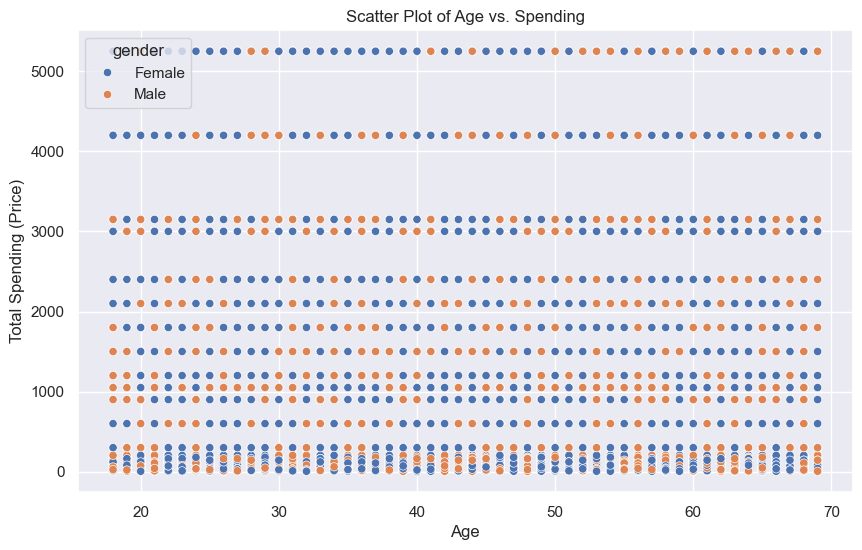

In [55]:
# To visualize the relationship between age and spending, and to see if there's any correlation between them.
plt.figure(figsize=(10, 6))  # figure size
sns.scatterplot(x='age', y='price', data=customer, hue='gender') # scatter plot with age on x-axis and spending on y-axis; differentiate points by gender
plt.title('Scatter Plot of Age vs. Spending') 
plt.xlabel('Age')  
plt.ylabel('Total Spending (Price)') 
plt.show() 

**Analysis:**  The data presented in the figure suggests that there is no clear relationship between a customer's age and their spending behavior. The spending scores appear to be uniformly distributed across the entire age range, from the early 20s to the late 60s. 
One notable observation is that the highest spending scores, around the $5,000 mark, are seen across a wide age spectrum. This indicates that high-spending customers exist throughout different stages of life, rather than being concentrated in a specific age gro. 

Additionally, the spending scores tend to cluster around certain distinct values, such as $1,000, $2,000, and $3,000. This pattern implies that the pricing or packaging of certain products or services may be leading customers to gravitate towards these specific spending levels, regardless of their gender or  e.

The scatter plot also uses different colors to differentiate between male and female customers. However, the overall distribution of spending scores across the age groups is quite similar for both genders. This suggests that gender is not a significant factor in determining an individual's spending behavior in relation to thei age.

In conclusion, the data seems to indicate that age is not a defining factor in shaping customer spending patterns. High spending occurs across various age groups, and certain pricing or product strategies may be driving customers towards specific spending thresholds. As such, marketing efforts should not be overly focused on targeting specific age segments, but rather on understanding the factors that influence spending behavior more broadly across the customer base.ior.

In [57]:
# Calculate the correlation between age and spending
correlation = customer['age'].corr(customer['price'])
print(f"Correlation between Age and Spending Score: {correlation:.2f}")


Correlation between Age and Spending Score: 0.00


**2.3 Bar Plot: Customer segmentation by different age group**

In [59]:
#  Segmenting Age Groups
# To categorize customers into age groups and compare the average spending across these groups.
# Creating age bins and corresponding labels
age_bins = [18, 25, 35, 45, 55, customer['age'].max()]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56+']
customer.loc[:, 'age_group'] = pd.cut(customer['age'], bins=age_bins, labels=age_labels, right=False)

# Calculating average spending score by age group
age_group_exp = customer.groupby('age_group', observed=True)['price'].mean().reset_index()

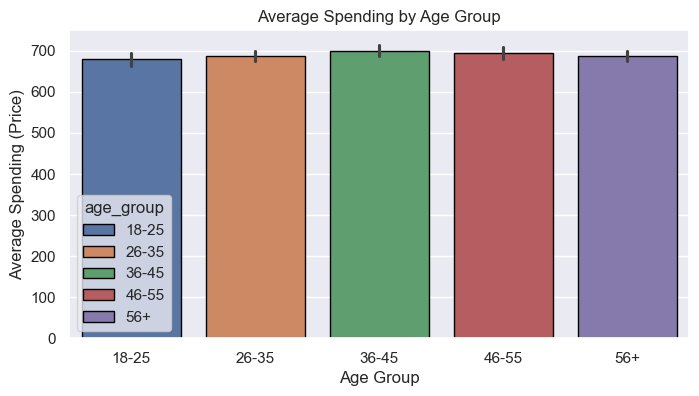

In [60]:
# displaying the average spending for each age group, helping to identify which age segments spend more.
plt.figure(figsize=(8, 4)) 
sns.barplot (x='age_group', y='price', data=customer , hue ='age_group', edgecolor = 'black') # age groups on x-axis and average spending on y-axis
plt.title('Average Spending by Age Group')  
plt.xlabel('Age Group')  
plt.ylabel('Average Spending (Price)')  
plt.show()  

In [61]:
print(age_group_exp)# Display the age group spending data

  age_group       price
0     18-25  678.801559
1     26-35  686.068044
2     36-45  700.261214
3     46-55  693.243982
4       56+  687.918397


**Analysis:** Every age group has comparable spending patterns. Compared to other age groups, those between the ages of 36 and 45 spend comparatively more on average; this could be because they earn more money. Those between the ages of 18 and 25 have the lowest average spending score; this could be because low income level; many people continue to study while unemployed, etc. In conclusion, The most profitable market segment is middle-aged adults. Marketing campaigns could be customized for this demographic, emphasizing their requirements and preferences. The company may take into account varioustechniques to attract younger clients, like providing products, discounts, or promotions that fit with their way of life. Spending may not be significantly impacted by age, behavior, as well as additional elements (like gender and payment) may need to be taken into account.

**2.4 Categories which should be targeted by shopping mall**

In [64]:
# Calculate average spending by category
category_avg_spending = customer.groupby('category')['price'].mean().reset_index()

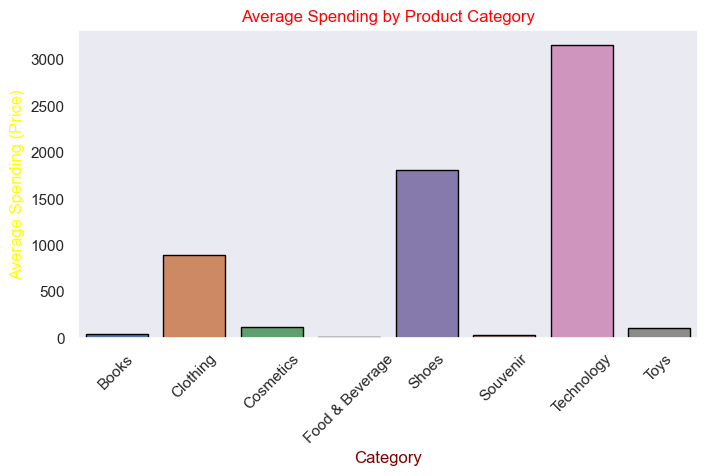

,category,price
0,Books,45.562583
1,Clothing,901.063836
2,Cosmetics,122.445994
3,Food & Beverage,15.671237
4,Shoes,1807.330114
5,Souvenir,34.894345
6,Technology,3157.357357
7,Toys,107.740379


In [65]:
# Visualize average spending by category
plt.figure(figsize=(8, 4))
sns.set_theme(style='dark')
sns.barplot(x='category', y='price', data=category_avg_spending, hue='category', edgecolor='black')
plt.title('Average Spending by Product Category', color='red')
plt.xlabel('Category', color='maroon')
plt.ylabel('Average Spending (Price)', color='yellow')
plt.xticks(rotation=45)
plt.show()
category_avg_spending

**Analysis:**  Based on the analysis presented in the bar graph, the shopping center should target the following customer segments/categories with its marketing efforts: - The category with the highest average spending is technology, followed by apparel and shoes. These areas should be the mall's primary focus for promotion because they probably generate a sizable portion of its total sales. They could provide promotions of new technology, time-limited offers, etc. It is important to consider categories other than the top three. Promotions for these markets may involve buy one, get one free offers, bundling offers, price breaks, etc. - Successful marketing techniques could involve customized promos, customized advertisements, and special offers or occasions. - Malls ought to provide customized offers to high-spenders in order to keep them as clients. - Malls can launch loyalty programs to draw in more patrons and boost

**Overall Analysis:**

**Marketing Campaigns:** The focus should be on high-spending age groups (26-45) and ensuring gender inclusivity in campaigns. Tailoring offers and messaging based on the specific interests and spending behavior of these segments.

**Product Positioning:** Offering premium products or experiences to high spenders, while providing budget-friendly options to lower-spending age groups.

**Customer Loyalty:** Identifying high-value outliers and create loyalty programs or exclusive offers to retain and further engage these customers.

### 3. Recommendation

**3.1 Sales By Payment Method**

In [173]:
# the code groups the customer DataFrame by the payment_method column
# calculating total sales
sales_by_paym = customer.groupby('payment_method')['price'].sum()

# Formating total sales for each payment method used
sales_by_paym_formatted = sales_by_paym.apply(lambda x: f"${x:,.2f}")
print(sales_by_paym_formatted)# Display the formatted result

payment_method
Cash           $30,701,457.13
Credit Card    $24,051,124.27
Debit Card     $13,791,114.39
Name: price, dtype: object


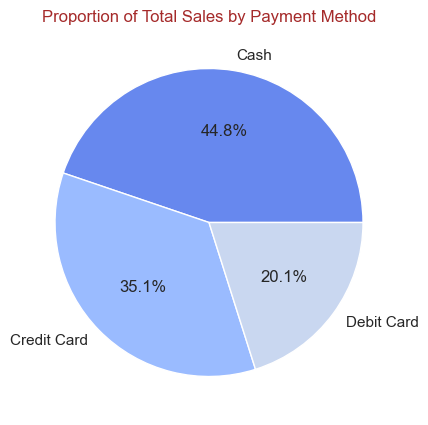

In [175]:
# total sales made by each payment_method 

plt.figure(figsize=(8, 5))
sales_by_paym.plot(kind='pie',autopct='%1.1f%%', colors=sns.color_palette('coolwarm'))
plt.title('Proportion of Total Sales by Payment Method', color='brown')
plt.ylabel('') # Hide the y-label
plt.show() #display piechart

**Analysis:** The pie chart reveals that while cash is the dominant payment method, there is a healthy diversity in how customers are paying, with a significant portion also using credit and debit cards. Cash is the most favored payment method among customers, making up 44.8% of the total sales. The second most popular payment method is the credit card, contributing 35.1% to the total sales. Debit cards also represent a significant share of total sales at 20.1%, though they are the least preferred payment option.

**3.2 Sales Trend Over Time**

In [129]:
# new column to store month and year
customer.loc[:, 'month_year'] = customer['invoice_date'].dt.to_period('M')

In [131]:
# Grouping by month and year, and calculating total monthly sales
monthly_sales = customer.groupby('month_year')['price'].sum()
monthly_sales.head()

month_year
2021-01    2655372.78
2021-02    2358636.34
2021-03    2618434.14
2021-04    2558825.62
2021-05    2662343.78
Freq: M, Name: price, dtype: float64

**Line chart to display the total monthly sales**

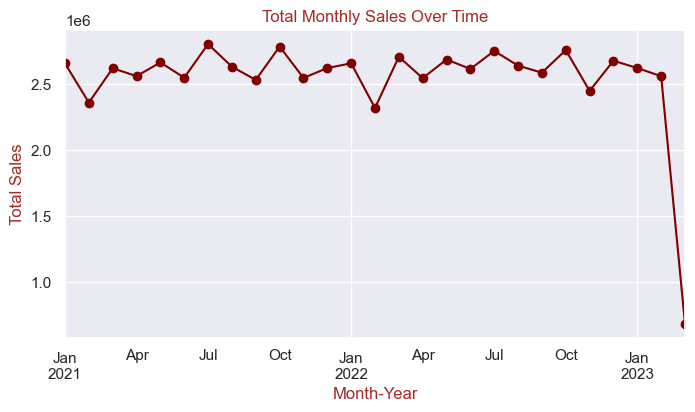

In [146]:
# plotting line chart
plt.figure(figsize=(8, 4))
sns.set(style ='darkgrid')
monthly_sales.plot(kind='line', marker='o', color='maroon')
plt.title('Total Monthly Sales Over Time', color='brown')
plt.xlabel('Month-Year', color='brown')
plt.ylabel('Total Sales', color='brown')
plt.grid(True)
plt.show()


**Observations:** From January 2021 to December 2022, the sales trend appears relatively stable, hovering around the 2.5 million mark. There are some fluctuations, but overall, the trend is consistent. The most striking observation is the significant drop in sales starting in January 2023. This drop is sharp and unprecedented when compared to the previous two years.

### Overall Recommendations for Dibs

*These recommendations will help Dibs better understand and serve its customers, optimize its sales and marketing strategies, and ultimately increase sales and customer loyalty.*

1. Analyze the purchase history to create customer segments (e.g., frequent buyers, high spenders, occasional shoppers).
2. Offer discounts on products that are frequently purchased or show a high level of customer interest.
3. Use historical data to plan and execute seasonal promotions during peak buying periods.
4. Actively monitor social media channels to address customer concerns and identify opportunities for improvement.
5. Continuously review product sales to determine which items are popular and which are underperforming, adjusting inventory and marketing focus accordingly.


<center> Thank you </center>